# Feature extraction and measurements

**Duration** ~40 min &nbsp;·&nbsp; **Session** Day 2, Python notebooks

Everything so far has been about *getting* a segmentation. None of it was the
point. Nobody publishes a binary image; what gets published is what the binary
image made it possible to measure.

This notebook turns a label image into a table of numbers, which is where image
analysis stops being about images and becomes ordinary data analysis.

**This notebook covers**

- turning a label image into a `pandas` table with `regionprops_table`
- morphology features versus intensity features, and when each is useful
- measuring one channel through another channel's binary image
- comparing a measured population between conditions

**Data**: `data/bbbc020/`, the nuclei and cells segmented so far.

## 1. From labels to a table

In [1]:
import re

import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt

from skimage.measure import regionprops_table

from course import DATA, show

FIELD = "2h_1"
nuclei = tifffile.imread(DATA / "bbbc020" / "images" / f"{FIELD}_nuclei.tif")
labels = tifffile.imread(DATA / "bbbc020" / "gt" / f"{FIELD}_nuclei_labels.tif")

print("label image:", labels.shape, labels.dtype, "|", labels.max(), "objects")

label image: (348, 512) uint16 | 39 objects


We are using the *annotated* labels here rather than our own segmentation, so
that the measurements are not confounded by segmentation error. In practice this
would be the output of a segmentation pipeline.

In [2]:
table = regionprops_table(
    labels,
    properties=("label", "area", "perimeter", "eccentricity", "solidity", "extent"),
)
features = pd.DataFrame(table)

print(features.shape)
features.head()

(39, 6)


,label,area,perimeter,eccentricity,solidity,extent
0,1,1306.0,135.982756,0.579911,0.973900,0.802211
1,2,321.0,84.627417,0.948399,0.966867,0.767943
2,3,478.0,92.662951,0.874902,0.979508,0.781046
3,4,822.0,103.840620,0.302381,0.977408,0.828629
4,5,617.0,93.941125,0.773015,0.967085,0.824866


One row per object, one column per measurement. That is the whole idea, and from
here on nothing is image-specific: this is a table, and tables are familiar
ground.

`regionprops_table` takes the property names as strings. There are dozens
available; the full list is in the
[`regionprops` documentation](https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops).

## 2. Morphology features

These describe **shape only**. They can be computed from the label image alone: 
no intensities involved.

| feature | meaning | intuition |
|---|---|---|
| `area` | pixels in the object | size |
| `perimeter` | pixels around its edge |: |
| `eccentricity` | 0 = circle, →1 = line | how elongated |
| `solidity` | area ÷ convex-hull area | how "dented"; 1 = convex |
| `extent` | area ÷ bounding-box area | how well it fills its box |

The last three are **dimensionless ratios**, which makes them far more portable
than `area`: they do not change with magnification.

In [3]:
features[["area", "perimeter", "eccentricity", "solidity", "extent"]].describe().round(2)

,area,perimeter,eccentricity,solidity,extent
count,39.00,39.00,39.00,39.00,39.00
mean,591.64,90.78,0.65,0.97,0.81
std,202.77,14.01,0.17,0.01,0.04
min,144.00,50.73,0.25,0.97,0.72
25%,505.50,84.53,0.58,0.97,0.78
50%,562.00,90.77,0.66,0.97,0.80
75%,668.00,96.36,0.75,0.98,0.82
max,1306.00,135.98,0.95,0.99,0.89


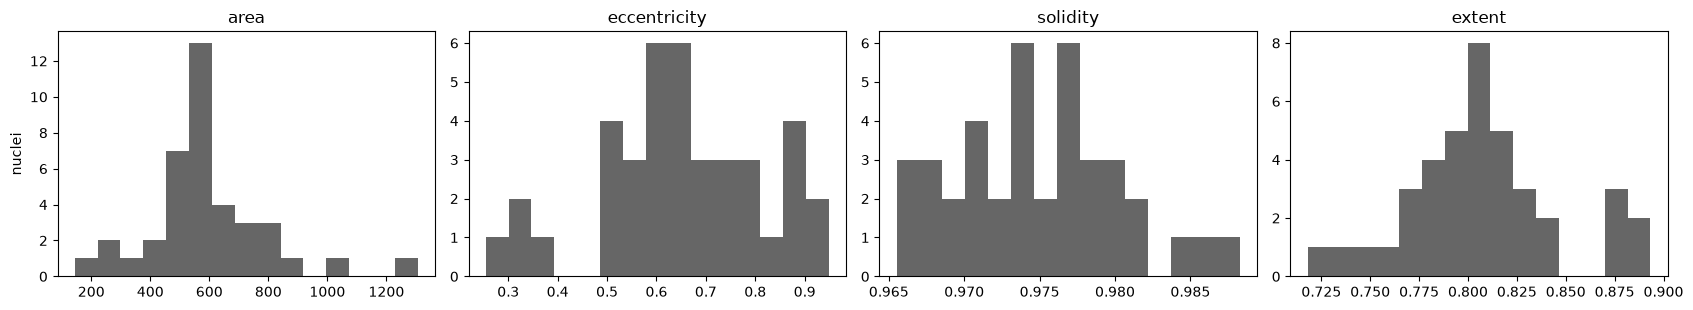

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(17, 3.2))
for ax, column in zip(axes, ["area", "eccentricity", "solidity", "extent"]):
    ax.hist(features[column], bins=15, color="0.4")
    ax.set_title(column)
    ax.set_ylabel("nuclei" if column == "area" else "")
plt.tight_layout()
plt.show()

Look at the spread. `area` ranges over a factor of nine, while `solidity` sits
between 0.97 and 0.99 for every single nucleus, because nuclei are convex blobs
and solidity measures exactly that.

**A feature with no variance carries no information.** Solidity is useless for
telling these nuclei apart. It will be extremely useful in the exercise, where
the objects are not all convex.

## 3. Intensity features

These need a second input: the image whose intensities are to be summarised inside
each object. Pass it as `intensity_image`.

This is the same idea as **Redirect to…** in Fiji's `Set Measurements`: the binary image
comes from one channel, the numbers from another.

In [5]:
cells = tifffile.imread(DATA / "bbbc020" / "images" / f"{FIELD}_cells.tif")

both = pd.DataFrame(regionprops_table(
    labels,
    intensity_image=cells,
    properties=("label", "area", "intensity_mean", "intensity_max", "intensity_min"),
))
both.head()

,label,area,intensity_mean,intensity_max,intensity_min
0,1,1306.0,89.003828,164.0,27.0
1,2,321.0,26.330218,34.0,19.0
2,3,478.0,58.673640,120.0,42.0
3,4,822.0,80.172749,172.0,59.0
4,5,617.0,173.572123,255.0,83.0


Every row is one nucleus, and `intensity_mean` is **how much CD11b sits inside
that nucleus's outline**.

That is the shape of a very large fraction of all quantitative microscopy: use a
reliable channel to find the objects, then measure the channel of interest inside
them. The homework is exactly this: nuclei from DAPI, signal from GFP.

dapi     114.2
cd11b     69.8


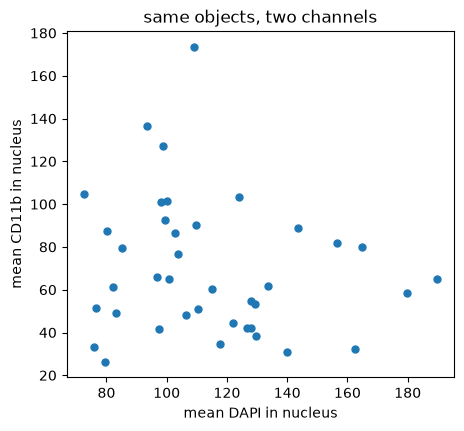

In [6]:
# The same objects, measured in each channel.
in_nuclei = pd.DataFrame(regionprops_table(
    labels, intensity_image=nuclei, properties=("label", "intensity_mean")
)).rename(columns={"intensity_mean": "dapi"})

in_cells = both[["label", "intensity_mean"]].rename(columns={"intensity_mean": "cd11b"})

merged = in_nuclei.merge(in_cells, on="label")
print(merged[["dapi", "cd11b"]].mean().round(1).to_string())

plt.figure(figsize=(5, 4.5))
plt.scatter(merged.dapi, merged.cd11b, s=25)
plt.xlabel("mean DAPI in nucleus")
plt.ylabel("mean CD11b in nucleus")
plt.title("same objects, two channels")
plt.show()

Same nuclei, two different numbers each, and no particular relationship between
them, which is what one would hope, since DAPI brightness and CD11b expression
have no reason to track each other.

**A strong diagonal in this plot would need explaining.** It is
usually a sign of bleed-through between channels, or of an autofluorescent
sample, and it would invalidate any claim that the two measurements are
independent.

## 4. Measuring across a whole experiment

One field is an anecdote. The value of doing this in code is that the same six
lines run over every image in the experiment.

In [7]:
def measure_field(field):
    """Every annotated nucleus in one field, measured in both channels."""
    labels = tifffile.imread(DATA / "bbbc020" / "gt" / f"{field}_nuclei_labels.tif")
    cells = tifffile.imread(DATA / "bbbc020" / "images" / f"{field}_cells.tif")

    table = pd.DataFrame(regionprops_table(
        labels,
        intensity_image=cells,
        properties=("label", "area", "eccentricity", "extent", "intensity_mean"),
    ))
    table["field"] = field
    # "15min_1" -> "15min", "Kontrolle1" -> "Kontrolle": strip the trailing
    # replicate number, with or without an underscore before it.
    table["condition"] = re.sub(r"_?\d+$", "", field)
    return table


fields = ["15min_1", "15min_2", "15min_3", "1h_1", "1h_2",
          "2h_1", "2h_2", "24h_1", "24h_2",
          "Kontrolle1", "Kontrolle2", "Kontrolle3"]

population = pd.concat([measure_field(f) for f in fields], ignore_index=True)
print(f"{len(population)} nuclei from {population.field.nunique()} fields")
population.groupby("condition").size().to_frame("nuclei")

309 nuclei from 12 fields


,nuclei
condition,
15min,72
1h,61
24h,42
2h,78
Kontrolle,56


Note the two extra columns. `field` keeps track of which image each object came
from, and `condition` groups the fields: `Kontrolle` is German for control, and
the rest are timepoints after stimulation.

**Always keep the identifying columns.** Pooling measurements from several images
loses the ability to trace a result back to its source, unless the source was
carried along.

## 5. Comparing conditions

In [8]:
summary = population.groupby("condition").agg(
    nuclei=("label", "size"),
    median_area=("area", "median"),
    median_cd11b=("intensity_mean", "median"),
).round(1)
summary

,nuclei,median_area,median_cd11b
condition,,,
15min,72,629.5,70.9
1h,61,595.0,60.4
24h,42,574.5,61.0
2h,78,540.5,58.9
Kontrolle,56,487.0,71.3


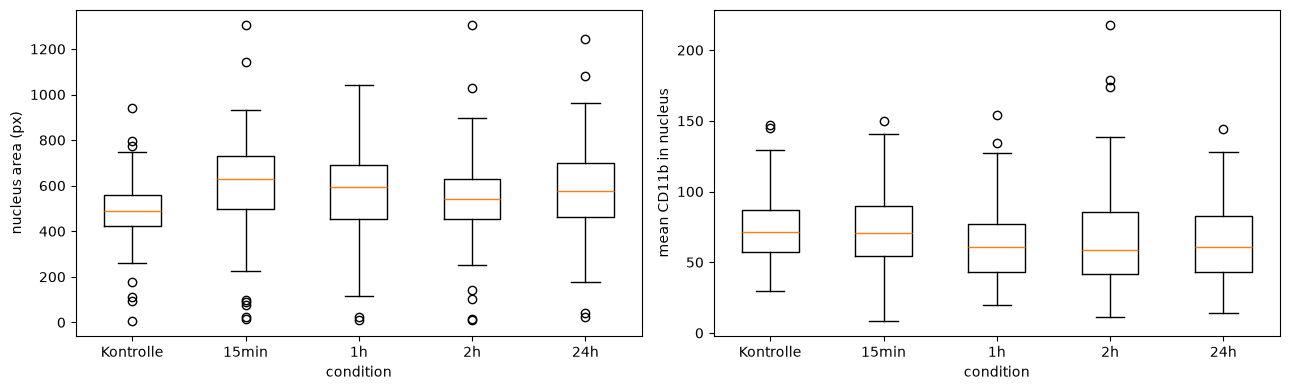

In [9]:
order = ["Kontrolle", "15min", "1h", "2h", "24h"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, column, ylabel in [
    (axes[0], "area", "nucleus area (px)"),
    (axes[1], "intensity_mean", "mean CD11b in nucleus"),
]:
    data = [population.loc[population.condition == c, column] for c in order]
    ax.boxplot(data, tick_labels=order)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("condition")
plt.tight_layout()
plt.show()

A box plot shows the whole distribution rather than just its middle, which
matters here: the boxes overlap heavily. Whatever difference exists between
conditions is small compared with the spread *within* each condition.

```{warning}
Conclusions from this need care. Each condition here is two or three fields from
one experiment, and the nuclei within a field are not independent observations:
they share a dish, a staining, a focus setting. Treating 300 nuclei as 300
independent samples would badly overstate the confidence.

The unit of replication is the *experiment*, not the cell. This is the single
most common statistical error in quantitative microscopy.
```

## 6. Which features actually distinguish anything?

In [10]:
# A quick way to see which features differ between two conditions: compare the
# separation between group medians with the spread inside the groups.
control = population[population.condition == "Kontrolle"]
late = population[population.condition == "24h"]

print(f"{'feature':16s} {'control':>9s} {'24h':>9s} {'difference':>11s}")
print("-" * 48)
for column in ["area", "eccentricity", "extent", "intensity_mean"]:
    a, b = control[column], late[column]
    pooled_sd = np.sqrt((a.var() + b.var()) / 2)
    effect = (b.mean() - a.mean()) / pooled_sd if pooled_sd else 0
    print(f"{column:16s} {a.median():9.2f} {b.median():9.2f} {effect:11.2f}")

feature            control       24h  difference
------------------------------------------------
area                487.00    574.50        0.44
eccentricity          0.73      0.76        0.34
extent                0.80      0.79       -0.21
intensity_mean       71.30     61.01       -0.37


That last column is the difference in means expressed in standard deviations: 
an **effect size**. It is far more informative than a p-value on its own, because
it says *how big* the difference is rather than only whether it is
detectable. A rule of thumb: 0.2 is small, 0.5 moderate, 0.8 large.

Notice that the features disagree about which condition differs and by how much.
That is normal, and it is why picking a feature after seeing the result is such a
dangerous habit: with enough features, something always looks significant.

## Recap

| | computed from | examples | portable across magnifications? |
|---|---|---|---|
| morphology | the label image alone | `area`, `eccentricity`, `solidity`, `extent` | ratios yes, `area` no |
| intensity | label image + an intensity image | `intensity_mean`, `intensity_max` | yes |

And the habits:

- keep `field` and `condition` columns so pooled measurements stay traceable;
- a feature with no variance carries no information;
- the unit of replication is the experiment, not the cell;
- report an effect size, not just a difference.

Next: `05_detective_game_ex`, which presents two kinds of object mixed together,
to be told apart from shape alone.